Kreuztabelle (Anzahl):
treatment        No  Yes
family_history          
No              495  272
Yes             127  365

Kreuztabelle (Prozent pro Family History):
treatment              No        Yes
family_history                      
No              64.537158  35.462842
Yes             25.813008  74.186992

Chi2-Statistik: 178.27
p-Wert: 0.0000
Freiheitsgrade: 1
Erwartete Häufigkeiten:
[[378.93089754 388.06910246]
 [243.06910246 248.93089754]]
Cramér's V: 0.376


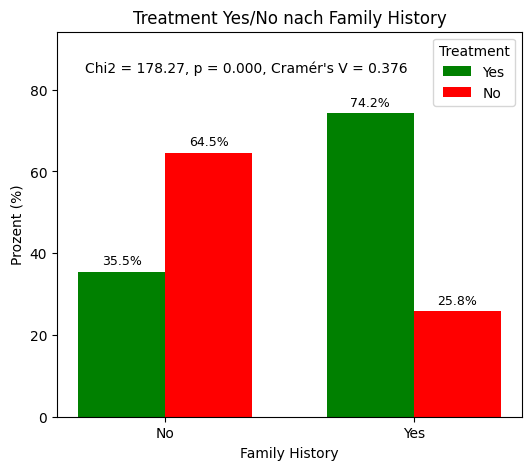

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import numpy as np

# --- Daten einlesen ---
df = pd.read_csv("survey.csv")

# --- Treatment standardisieren ---
df['treatment'] = df['treatment'].str.strip().str.capitalize()  # Yes/No

# --- Family History standardisieren ---
df['family_history'] = df['family_history'].str.strip().str.capitalize()  # Yes/No

# --- Kreuztabelle Treatment vs Family History ---
ct_family = pd.crosstab(df['family_history'], df['treatment'])
print("Kreuztabelle (Anzahl):")
print(ct_family)

ct_family_percent = pd.crosstab(df['family_history'], df['treatment'], normalize='index') * 100
print("\nKreuztabelle (Prozent pro Family History):")
print(ct_family_percent)

# --- Chi-Quadrat-Test ---
chi2, p, dof, expected = chi2_contingency(ct_family)
print(f"\nChi2-Statistik: {chi2:.2f}")
print(f"p-Wert: {p:.4f}")
print(f"Freiheitsgrade: {dof}")
print("Erwartete Häufigkeiten:")
print(expected)

# --- Effektgröße (Cramér's V) ---
n = ct_family.to_numpy().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct_family.shape)-1)))
print(f"Cramér's V: {cramers_v:.3f}")

# --- Balkendiagramm mit Prozentangaben, Yes links ---
fig, ax = plt.subplots(figsize=(6,5))
width = 0.35
categories = ct_family_percent.index.tolist()
treatments = ['Yes', 'No']  # Reihenfolge fixieren
x = range(len(categories))
colors = {"Yes": "green", "No": "red"}

for i, treatment in enumerate(treatments):
    heights = ct_family_percent[treatment].values
    ax.bar([p + i*width for p in x], heights, width=width, label=treatment, color=colors[treatment])
    for j, h in enumerate(heights):
        ax.text(j + i*width, h + 1, f"{h:.1f}%", ha='center', va='bottom', fontsize=9)

# --- Signifikanzannotation mittig ---
x_mitte = (0 + len(categories) - 1) / 2
y_hoch = ct_family_percent.values.max() + 10
ax.text(x_mitte, y_hoch, 
        f"Chi2 = {chi2:.2f}, p = {p:.3f}, Cramér's V = {cramers_v:.3f}", 
        fontsize=10, ha='center')

# Achsen, Titel, Legend
ax.set_xticks([p + width/2 for p in x])
ax.set_xticklabels(categories)
ax.set_ylabel("Prozent (%)")
ax.set_xlabel("Family History")
ax.set_title("Treatment Yes/No nach Family History")
ax.set_ylim(0, ct_family_percent.values.max() + 20)
ax.legend(title="Treatment")

plt.show()